In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_excel('heart_disease.xlsx', sheet_name=1)
df.shape

(908, 13)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [57]:
df['exang'].unique()

array([False, True, 'FALSE', 'TURE'], dtype=object)

In [7]:
df['cp'].unique()

array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)

In [8]:
df['restecg'].unique()

array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)

In [9]:
df['slope'].unique()

array(['downsloping', 'flat', 'upsloping'], dtype=object)

In [10]:
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

- there are missing values in the data

<Axes: xlabel='oldpeak'>

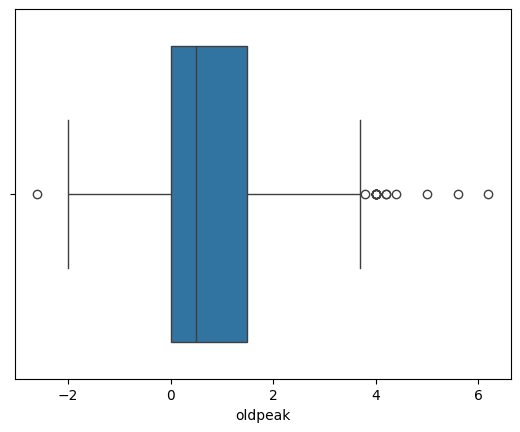

In [11]:
sns.boxplot(x=df['oldpeak'])

<Axes: xlabel='oldpeak', ylabel='Count'>

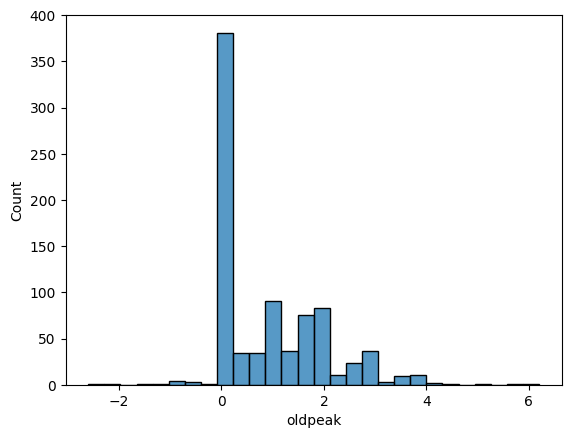

In [14]:
sns.histplot(x=df['oldpeak'])

Since oldpeak is a continuous numerical feature and may contain outliers, median is usually preferred.

In [15]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_15488\4171898574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


In [16]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [17]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.864537,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.060433,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [21]:
cols = ["trestbps", "chol", "thalch", "oldpeak"]

array([[<Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalch'}>,
        <Axes: title={'center': 'oldpeak'}>]], dtype=object)

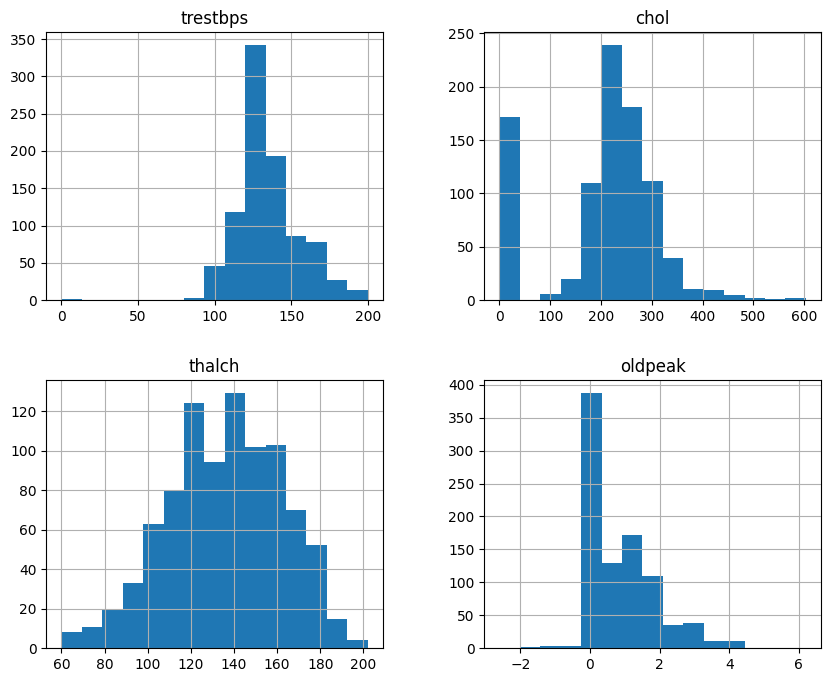

In [22]:
df[cols].hist(figsize=(10,8), bins=15)

<Axes: >

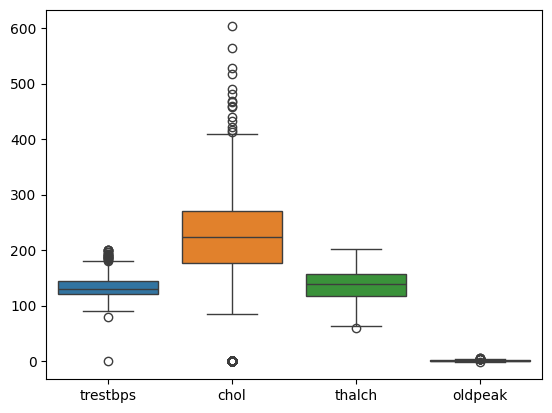

In [23]:
sns.boxplot(data = df[cols])

In [25]:
df[df['chol'] == 0].count()

age         172
sex         172
cp          172
trestbps    172
chol        172
fbs         172
restecg     172
thalch      172
exang       172
oldpeak     172
slope       172
thal        172
num         172
dtype: int64

A cholesterol value of 0 mg/dL is physiologically impossible.

In [26]:
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'].fillna(df['chol'].median(), inplace=True)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_15488\3843958458.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['chol'].fillna(df['chol'].median(), inplace=True)


In [31]:
df[df['trestbps'] == 0]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
842,55,Male,non-anginal,0,240.0,False,normal,155,False,1.5,flat,fixed defect,3


Blood pressure cannot be 0 for a living patient.

In [32]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['trestbps'].fillna(df['trestbps'].median(), inplace=True)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_15488\2748251748.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(df['trestbps'].median(), inplace=True)


In [35]:
df['thalch'].describe()

count    908.000000
mean     135.957048
std       26.804929
min       60.000000
25%      118.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: thalch, dtype: float64

- Values between 60 and 200 are generally possible.
- so i would keep these outliers

In [37]:
df[df['oldpeak'] < 0].count()

age         12
sex         12
cp          12
trestbps    12
chol        12
fbs         12
restecg     12
thalch      12
exang       12
oldpeak     12
slope       12
thal        12
num         12
dtype: int64

- here value less then 0 is impossible 

In [39]:
df.loc[df['oldpeak'] < 0, 'oldpeak'] = np.nan
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_15488\1412592060.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)


<Axes: >

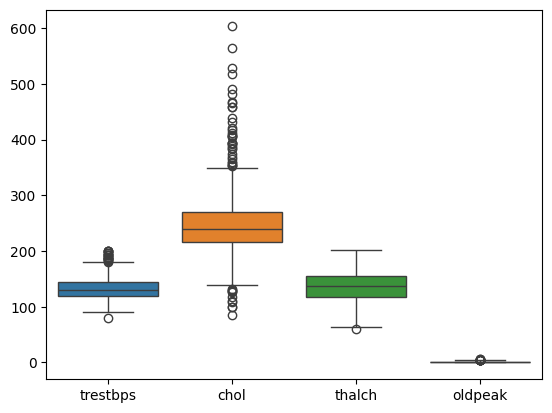

In [41]:
sns.boxplot(data = df[cols])

In [42]:
from sklearn.preprocessing import RobustScaler

In [44]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

scaler = RobustScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

Outliers were examined using boxplots. Since the dataset contains medical measurements, extreme values may represent genuine patient conditions rather than errors. Impossible values such as cholesterol = 0 and resting blood pressure = 0 were treated as missing values and imputed using the median. Valid extreme observations were retained, and Robust Scaling was applied to reduce the influence of outliers during model training.

#### 3. Feature Engineering:

In [52]:
# applying ordinal encoding for 'fbs' and 'exang' features
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [53]:
df['fbs'] = df['fbs'].map({True: 0, False: 1})

- there some durty data in the 'exang' column

In [59]:
df['exang'] = df['exang'].astype(str).str.upper().replace({
    'TRUE': True, 
    'TURE': True,    # Fixes your typo
    'FALSE': False, 
    'FALSE': False
})

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_15488\3355660072.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].astype(str).str.upper().replace({


In [60]:
encoder = OrdinalEncoder(categories=[[False, True]])
df['exang'] = encoder.fit_transform(df[['exang']])

In [61]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,0.734694,Male,typical angina,0.625000,-0.129630,0,lv hypertrophy,0.315789,0.0,1.200000,downsloping,fixed defect,0
1,-1.061224,Male,atypical angina,0.208333,-0.685185,1,normal,-0.157895,0.0,-0.333333,flat,fixed defect,0
2,0.244898,Male,asymptomatic,0.416667,-0.888889,1,normal,0.263158,0.0,-0.066667,flat,fixed defect,0
3,-0.163265,Male,typical angina,-0.500000,-1.000000,1,lv hypertrophy,1.368421,0.0,-0.333333,flat,fixed defect,0
4,0.244898,Male,asymptomatic,-0.833333,-0.722222,1,normal,-0.315789,1.0,0.666667,flat,fixed defect,0


In [62]:
# applying one-hot encoding to rest catogorical variable 
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform
encoded_data = encoder.fit_transform(df[['sex', 'cp', 'restecg', 'slope', 'thal']])

# Convert back to a readable DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['sex', 'cp', 'restecg', 'slope', 'thal']))
df_final = pd.concat([df, encoded_df], axis=1)

In [64]:
df_final.drop(columns=(['sex', 'cp', 'restecg', 'slope', 'thal']), inplace=True)

In [69]:
df_final.columns

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'num',
       'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina',
       'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy',
       'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping',
       'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')

#### 4. Decision Tree Classification:

In [ ]:
y = df_final['num']
x = df_final.drop(columns=['num'])

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [79]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [80]:
y_pred = dt_model.predict(x_test)

# Probabilities for ROC-AUC
y_prob = dt_model.predict_proba(x_test)[:, 1]

In [81]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [89]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.49150540846006213
Recall: 0.5
F1 Score: 0.4952154722559689


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73        89
           1       0.31      0.31      0.31        48
           2       0.33      0.27      0.30        22
           3       0.21      0.24      0.22        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.31      0.31      0.31       182
weighted avg       0.49      0.50      0.50       182



In [92]:
from sklearn.model_selection import GridSearchCV

In [99]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

# Best tuned model
best_dt = grid_search.best_estimator_

In [100]:
y_prob = best_dt.predict_proba(x_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.7676370662317942


#### 5. Hyperparameter Tuning:

In [104]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': [None, 'balanced']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',   # better than accuracy for imbalanced multiclass data
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best CV Score:
0.49722301147394504


C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


#### 6. Model Evaluation and Analysis:

Accuracy

The model achieved an accuracy of approximately 50%, meaning that half of the test instances were classified correctly.

The Decision Tree model achieved moderate predictive performance with an accuracy of 50% and a ROC-AUC score of 0.768. The model performed well on the majority class but struggled to correctly classify minority classes due to class imbalance. Feature importance analysis revealed the most influential predictors used by the tree. Although the model is easy to interpret and visualize, its performance on minority classes suggests that additional techniques such as class balancing, pruning, ensemble methods, or Random Forests could improve classification performance.

### Interview Questions:

1)What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Maximum Depth (max_depth)

The max_depth parameter determines the maximum depth of the tree.

- A smaller depth produces a simpler model that may underfit the data.
- A larger depth allows the model to learn more complex patterns but may lead to overfitting.

Minimum Samples Split (min_samples_split)

This parameter specifies the minimum number of samples required to split an internal node.

- Smaller values allow more splits and can increase model complexity.
- Larger values reduce unnecessary splits and help improve generalization.

Minimum Samples Leaf (min_samples_leaf)

This parameter specifies the minimum number of samples that must be present in a leaf node.

- Higher values prevent the creation of very small leaf nodes.
- It helps reduce overfitting and improves model stability.

Criterion

- Common options include:
  - Gini Impurity (gini)
  - Information Gain (entropy)

The criterion parameter determines how the quality of a split is measured. Both methods aim to create pure child nodes, although entropy generally requires more computation.

Maximum Features (max_features)

This parameter controls the number of features considered when searching for the best split.

- Smaller values reduce variance and improve generalization.
- Larger values allow the model to consider more information at each split.

Conclusion

Hyperparameter tuning is important because it helps balance model complexity and predictive performance. Properly tuned Decision Trees achieve better accuracy and generalize more effectively to unseen data.

2. What is the difference between the Label encoding and One-hot encoding?

Machine learning algorithms require numerical input. Label Encoding and One-Hot Encoding are two common techniques used to convert categorical variables into numerical form.

Label Encoding - Label Encoding assigns a unique integer value to each category. 
- Advantages
  - Simple and memory efficient.
  - Suitable for ordinal data where categories have a natural order.
- Disadvantages
  - Introduces an artificial order among categories.
  - Some machine learning algorithms may incorrectly assume that higher numbers represent higher importance.

One-Hot Encoding - One-Hot Encoding creates a separate binary column for each category.
- Advantages
  - Does not introduce any order between categories.
  - Suitable for nominal categorical variables.
- Disadvantages
  - Increases the number of features.
  - Can lead to high dimensionality when a feature contains many unique categories.

Conclusion

Label Encoding should be used for ordinal categorical variables where categories have a meaningful order, while One-Hot Encoding should be used for nominal categorical variables where no natural ordering exists. One-Hot Encoding is generally preferred because it avoids introducing artificial relationships between categories.